In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import linregress

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchmetrics.regression import ContinuousRankedProbabilityScore
import shap

import seaborn as sns
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import KFold

import os
import datetime
import random

In [106]:

# Ida's plot colours
from matplotlib.colors import LinearSegmentedColormap, Normalize,ListedColormap, BoundaryNorm
import matplotlib

matplotlib.rcParams['font.family'] = 'Liberation Sans'

# DTU color scheme
dtu_navy = '#030F4F'
dtu_red = '#990000'
dtu_grey = '#DADADA'
white = '#ffffff'
black = '#000000'

# Color intermediates
phase1_blue = '#030F4F'
phase2_blue = '#3d4677'
phase3_blue = '#babecf'
phase1_red = '#990000'
phase2_red = '#bc5959'
phase3_red = '#e6c1c1'

# Color lists for colormaps
dtu_coolwarm = [dtu_navy, white, dtu_red]
dtu_blues = ['#030f4f',white]
dtu_reds = [white,dtu_red]

# Custom colormaps
dtu_coolwarm_cmap = LinearSegmentedColormap.from_list("dtu_coolwarm", dtu_coolwarm)
dtu_blues_cmap = LinearSegmentedColormap.from_list("dtu_blues", dtu_blues)
dtu_reds_cmap = LinearSegmentedColormap.from_list("dtu_reds", dtu_reds)

## Load data

In [107]:
df_train = pd.read_csv("./filter_mu_atmo_surf_obs2345_promistK.csv")
df_test = pd.read_csv("./mashup_2025.csv")

## temperature departure ch4_obs-sim sanity limits
maxTdep = 60.0   ## 5.0 for ch4; 6.0 for ist
minTdep = -20.550    ## -1.45 for ch4; -0.55 for ist

## Max distance between center_pixel and reference_AWS positions
max_distance_meters_pixelobs = 7
## Max difference between 2MT_nwp og 2MTDew_nwp. 0-15 K is range in data set 
max_difference_2mt_2mtdew = 15
## temperature sanity limits
maxt = 270.0 # -3°C 
mint = 200.0 # -73°C
## solar-zenith angle limits
maxsunzen = 180.0
minsunzen = 0.0
## Promice CAF upper limit
maxcaf = 1.2
## Maximum view angle
maxview = 75.0
## quality level range, ql greater than X
qlgrt = 0
## for statistics of each station
# this dataset is EGP, KAN_U, UPE_U, KPC_U
station = "EGP"
station0 = "KAN_U"

## Filter data with multople conditions

df_train = df_train.loc[
    (df_train["lev1_sunzenith_angle"] >= minsunzen) & 
    (df_train["lev1_sunzenith_angle"] < maxsunzen) & 
    (df_train["lev1_satzenith_angle"] < maxview) & 
    (df_train["satcenter_station_dist_km"] < abs(max_distance_meters_pixelobs)) &     
    (df_train["lev2_quality_level"] > qlgrt) & 
    (df_train["lev2_surface_temperature"] > mint) & 
    (df_train["lev2_surface_temperature"] < maxt) & 
    (df_train["CloudCover"] < maxcaf) & 
    (df_train["nwp_t2m"]-df_train["nwp_d2m"] < max_difference_2mt_2mtdew) & 
    (df_train["SurfaceTemperature(C)"] > mint-273.15) & 
    (df_train["SurfaceTemperature(C)"] < maxt-273.15) &
    (df_train["station_id"] == station) | (df_train["station_id"] == station0)]

df_train = df_train.sort_values('lev1_obstime', ascending=True)

df_test = df_test.loc[
    (df_test["lev1_sunzenith_angle"] >= minsunzen) & 
    (df_test["lev1_sunzenith_angle"] < maxsunzen) & 
    (df_test["lev1_satzenith_angle"] < maxview) & 
    (df_test["satcenter_station_dist_km"] < abs(max_distance_meters_pixelobs)) &     
    (df_test["lev2_quality_level"] > qlgrt) & 
    (df_test["lev2_surface_temperature"] > mint) & 
    (df_test["lev2_surface_temperature"] < maxt) & 
    (df_test["CloudCover"] < maxcaf) & 
    (df_test["nwp_t2m"]-df_test["nwp_d2m"] < max_difference_2mt_2mtdew) & 
    (df_test["SurfaceTemperature(C)"] > mint-273.15) & 
    (df_test["SurfaceTemperature(C)"] < maxt-273.15) &
    (df_test["station_id"] == station) | (df_test["station_id"] == station0)]

df_test = df_test.sort_values('lev1_obstime', ascending=True)

## Model features

In [108]:
# With channel5
input_features = [
    "lev2_surface_temperature", "lev1_channel4", "nwp_skt", "nwp_d2m", "nwp_t2m", "nwp_tcw", "lev1_sunzenith_angle",
    "nwp_t_800_hPa", "nwp_t_850_hPa", "nwp_t_700_hPa", "nwp_t_1000_hPa", "nwp_t_950_hPa", "nwp_t_925_hPa", "nwp_t_900_hPa", "nwp_t_600_hPa", "nwp_t_500_hPa",
    "nwp_q_1000_hPa", "nwp_q_925_hPa", "nwp_q_950_hPa", "nwp_q_900_hPa", "nwp_q_850_hPa", "nwp_q_800_hPa",
    "lev1_channel5"
]

# No channel5
input_features2 = [
    "lev2_surface_temperature", "lev1_channel4", "nwp_skt", "nwp_d2m", "nwp_t2m", "nwp_tcw", "lev1_sunzenith_angle",
    "nwp_t_800_hPa", "nwp_t_850_hPa", "nwp_t_700_hPa", "nwp_t_1000_hPa", "nwp_t_950_hPa", "nwp_t_925_hPa", "nwp_t_900_hPa", "nwp_t_600_hPa", "nwp_t_500_hPa",
    "nwp_q_1000_hPa", "nwp_q_925_hPa", "nwp_q_950_hPa", "nwp_q_900_hPa", "nwp_q_850_hPa", "nwp_q_800_hPa"
]

target_column = "promistK"

## Clean: drop rows with missing data
# Keep test data columns needed for plotting and classical algorithms
# Note: lev1_satzenith_angle is required for algo9

# These initial definitions are not used directly for training, but keep them aligned with the later cleaned data.
df_clean_train = df_train[input_features + [target_column] + ['lev1_obstime']].dropna()
df_clean_test = df_test[input_features + [target_column] + ['lev1_satzenith_angle', 'lev1_obstime']].dropna()
df_clean_train2 = df_train[input_features2 + [target_column] + ['lev1_obstime']].dropna()
df_clean_test2 = df_test[input_features2 + [target_column] + ['lev1_obstime']].dropna()


In [109]:
# Use df_train for training, df_test for testing

# Validate features in df_train and df_test
available_input_features = [f for f in input_features if f in df_train.columns and f in df_test.columns]
missing_train = [f for f in input_features if f not in df_train.columns]
missing_test = [f for f in input_features if f not in df_test.columns]
if missing_train:
    print(f"Warning: missing input_features in df_train: {missing_train}")
if missing_test:
    print(f"Warning: missing input_features in df_test: {missing_test}")

available_input_features2 = [f for f in input_features2 if f in df_train.columns and f in df_test.columns]
missing_train2 = [f for f in input_features2 if f not in df_train.columns]
missing_test2 = [f for f in input_features2 if f not in df_test.columns]
if missing_train2:
    print(f"Warning: missing input_features2 in df_train: {missing_train2}")
if missing_test2:
    print(f"Warning: missing input_features2 in df_test: {missing_test2}")

if len(available_input_features) == 0:
    raise ValueError('No available input_features found.')

# Clean data
df_clean_train = df_train[available_input_features + [target_column] + ['lev1_obstime']].dropna()
df_clean_test = df_test[available_input_features + [target_column] + ['lev1_satzenith_angle', 'lev1_obstime']].dropna()
df_clean_train2 = df_train[available_input_features2 + [target_column] + ['lev1_obstime']].dropna()
df_clean_test2 = df_test[available_input_features2 + [target_column] + ['lev1_obstime', 'lev1_obstime']].dropna()

print(f"Using input_features: {available_input_features}")
print(f"Using input_features2: {available_input_features2}")

X_train = df_clean_train[available_input_features].values
X_test = df_clean_test[available_input_features].values
y_train = df_clean_train[target_column].values
y_test = df_clean_test[target_column].values

X_train2 = df_clean_train2[available_input_features2].values
X_test2 = df_clean_test2[available_input_features2].values
y_train2 = df_clean_train2[target_column].values
y_test2 = df_clean_test2[target_column].values

print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Train2 samples: {len(X_train2)}")
print(f"Test2 samples: {len(X_test2)}")

Using input_features: ['lev2_surface_temperature', 'lev1_channel4', 'nwp_skt', 'nwp_d2m', 'nwp_t2m', 'nwp_tcw', 'lev1_sunzenith_angle', 'nwp_t_800_hPa', 'nwp_t_850_hPa', 'nwp_t_700_hPa', 'nwp_t_1000_hPa', 'nwp_t_950_hPa', 'nwp_t_925_hPa', 'nwp_t_900_hPa', 'nwp_t_600_hPa', 'nwp_t_500_hPa', 'nwp_q_1000_hPa', 'nwp_q_925_hPa', 'nwp_q_950_hPa', 'nwp_q_900_hPa', 'nwp_q_850_hPa', 'nwp_q_800_hPa', 'lev1_channel5']
Using input_features2: ['lev2_surface_temperature', 'lev1_channel4', 'nwp_skt', 'nwp_d2m', 'nwp_t2m', 'nwp_tcw', 'lev1_sunzenith_angle', 'nwp_t_800_hPa', 'nwp_t_850_hPa', 'nwp_t_700_hPa', 'nwp_t_1000_hPa', 'nwp_t_950_hPa', 'nwp_t_925_hPa', 'nwp_t_900_hPa', 'nwp_t_600_hPa', 'nwp_t_500_hPa', 'nwp_q_1000_hPa', 'nwp_q_925_hPa', 'nwp_q_950_hPa', 'nwp_q_900_hPa', 'nwp_q_850_hPa', 'nwp_q_800_hPa']
Train samples: 2699
Test samples: 169
Train2 samples: 2699
Test2 samples: 169


In [110]:
# Use df_train for training, df_test for testing

# Validate features in df_train and df_test
available_input_features = [f for f in input_features if f in df_train.columns and f in df_test.columns]
missing_train = [f for f in input_features if f not in df_train.columns]
missing_test = [f for f in input_features if f not in df_test.columns]
if missing_train:
    print(f"Warning: missing input_features in df_train: {missing_train}")
if missing_test:
    print(f"Warning: missing input_features in df_test: {missing_test}")

available_input_features2 = [f for f in input_features2 if f in df_train.columns and f in df_test.columns]
missing_train2 = [f for f in input_features2 if f not in df_train.columns]
missing_test2 = [f for f in input_features2 if f not in df_test.columns]
if missing_train2:
    print(f"Warning: missing input_features2 in df_train: {missing_train2}")
if missing_test2:
    print(f"Warning: missing input_features2 in df_test: {missing_test2}")

if len(available_input_features) == 0:
    raise ValueError('No available input_features found.')

# Clean data
df_clean_train = df_train[available_input_features + [target_column] + ['lev1_obstime']].dropna()
df_clean_test = df_test[available_input_features + [target_column] + ['lev1_satzenith_angle', 'lev1_obstime']].dropna()
df_clean_train2 = df_train[available_input_features2 + [target_column] + ['lev1_obstime']].dropna()
df_clean_test2 = df_test[available_input_features2 + [target_column] + ['lev1_obstime']].dropna()

print(f"Using input_features: {available_input_features}")
print(f"Using input_features2: {available_input_features2}")

X_train = df_clean_train[available_input_features].values
X_test = df_clean_test[available_input_features].values
y_train = df_clean_train[target_column].values
y_test = df_clean_test[target_column].values

X_train2 = df_clean_train2[available_input_features2].values
X_test2 = df_clean_test2[available_input_features2].values
y_train2 = df_clean_train2[target_column].values
y_test2 = df_clean_test2[target_column].values

print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Train2 samples: {len(X_train2)}")
print(f"Test2 samples: {len(X_test2)}")

Using input_features: ['lev2_surface_temperature', 'lev1_channel4', 'nwp_skt', 'nwp_d2m', 'nwp_t2m', 'nwp_tcw', 'lev1_sunzenith_angle', 'nwp_t_800_hPa', 'nwp_t_850_hPa', 'nwp_t_700_hPa', 'nwp_t_1000_hPa', 'nwp_t_950_hPa', 'nwp_t_925_hPa', 'nwp_t_900_hPa', 'nwp_t_600_hPa', 'nwp_t_500_hPa', 'nwp_q_1000_hPa', 'nwp_q_925_hPa', 'nwp_q_950_hPa', 'nwp_q_900_hPa', 'nwp_q_850_hPa', 'nwp_q_800_hPa', 'lev1_channel5']
Using input_features2: ['lev2_surface_temperature', 'lev1_channel4', 'nwp_skt', 'nwp_d2m', 'nwp_t2m', 'nwp_tcw', 'lev1_sunzenith_angle', 'nwp_t_800_hPa', 'nwp_t_850_hPa', 'nwp_t_700_hPa', 'nwp_t_1000_hPa', 'nwp_t_950_hPa', 'nwp_t_925_hPa', 'nwp_t_900_hPa', 'nwp_t_600_hPa', 'nwp_t_500_hPa', 'nwp_q_1000_hPa', 'nwp_q_925_hPa', 'nwp_q_950_hPa', 'nwp_q_900_hPa', 'nwp_q_850_hPa', 'nwp_q_800_hPa']
Train samples: 2699
Test samples: 169
Train2 samples: 2699
Test2 samples: 169


## Datasets and Normalised Dataloader

In [111]:
class ISTDataset(Dataset):
    def __init__(self, X, y): # X: the input features and y: the labels (e.g.the ground truth IST)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self): # Returns the number of samples in your dataset. Required by PyTorch to know how many batches to expect.
        return len(self.X)

    def __getitem__(self, idx): #Returns a single sample (features & target) by index.PyTorch uses this to load data batch-by-batch during training.
        return self.X[idx], self.y[idx]

# Fit only on training data
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

train_mean2 = X_train2.mean(axis=0)
train_std2 = X_train2.std(axis=0)

# Apply to both
X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

X_train_scaled2 = (X_train2 - train_mean2) / train_std2
X_test_scaled2 = (X_test2 - train_mean2) / train_std2

# Create datasets
train_dataset = ISTDataset(X_train_scaled, y_train)
test_dataset = ISTDataset(X_test_scaled, y_test)

train_dataset2 = ISTDataset(X_train_scaled2, y_train2)
test_dataset2 = ISTDataset(X_test_scaled2, y_test2)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

train_loader2 = DataLoader(train_dataset2, batch_size=32, shuffle=True)
test_loader2 = DataLoader(test_dataset2, batch_size=32, shuffle=False)

print(X_train.shape)
print(X_train2.shape)

(2699, 23)
(2699, 22)


## Simple model

In [112]:
# MODEL: Define a simple neural network
class SimpleRegressor(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)
    
model = SimpleRegressor(len(input_features))
model2 = SimpleRegressor(len(input_features2))

## Training

In [113]:
# Set up training tools
lr = 1e-3 # learning rate
loss_fn = nn.MSELoss() # mean squared error bc regression task
optimizer = torch.optim.Adam(model.parameters(), lr=lr) # using Adam, a common and effective optimization algorithm
optimizer2 = torch.optim.Adam(model2.parameters(), lr=lr)

#  Train the model
model.train()
model2.train()

epochs = 100 # NB 50 EPOCHS INSTEAD OF 100 FOR TRAINING
epoch_losses = [] # to stock the loss and track the learning of my model
epoch_losses2 = []
all_batch_losses = []
all_batch_losses2 = []
    

for epoch in range(epochs):
    running_loss = 0.0
    running_loss2 = 0.0
    num_batches = 0
    num_batches2 = 0
    
    for X_batch, y_batch in train_loader:
        preds = model(X_batch)
        loss = loss_fn(preds, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        num_batches += 1
        all_batch_losses.append(loss.item())  # Store each batch loss

    for X_batch, y_batch in train_loader2:
        preds = model2(X_batch)
        loss2 = loss_fn(preds, y_batch)
        optimizer2.zero_grad()
        loss2.backward()
        optimizer2.step()

        running_loss2 += loss2.item()
        num_batches2 += 1
        all_batch_losses2.append(loss2.item())

    avg_loss = running_loss / num_batches
    epoch_losses.append(avg_loss)

    avg_loss2 = running_loss2 / num_batches2
    epoch_losses2.append(avg_loss2)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")


Epoch 0 | Loss: 43694.7109
Epoch 10 | Loss: 425.7339
Epoch 20 | Loss: 101.3029
Epoch 30 | Loss: 16.7810
Epoch 40 | Loss: 19.2462
Epoch 50 | Loss: 5.7496
Epoch 60 | Loss: 10.0390
Epoch 70 | Loss: 8.4444
Epoch 80 | Loss: 2.8782
Epoch 90 | Loss: 9.3135


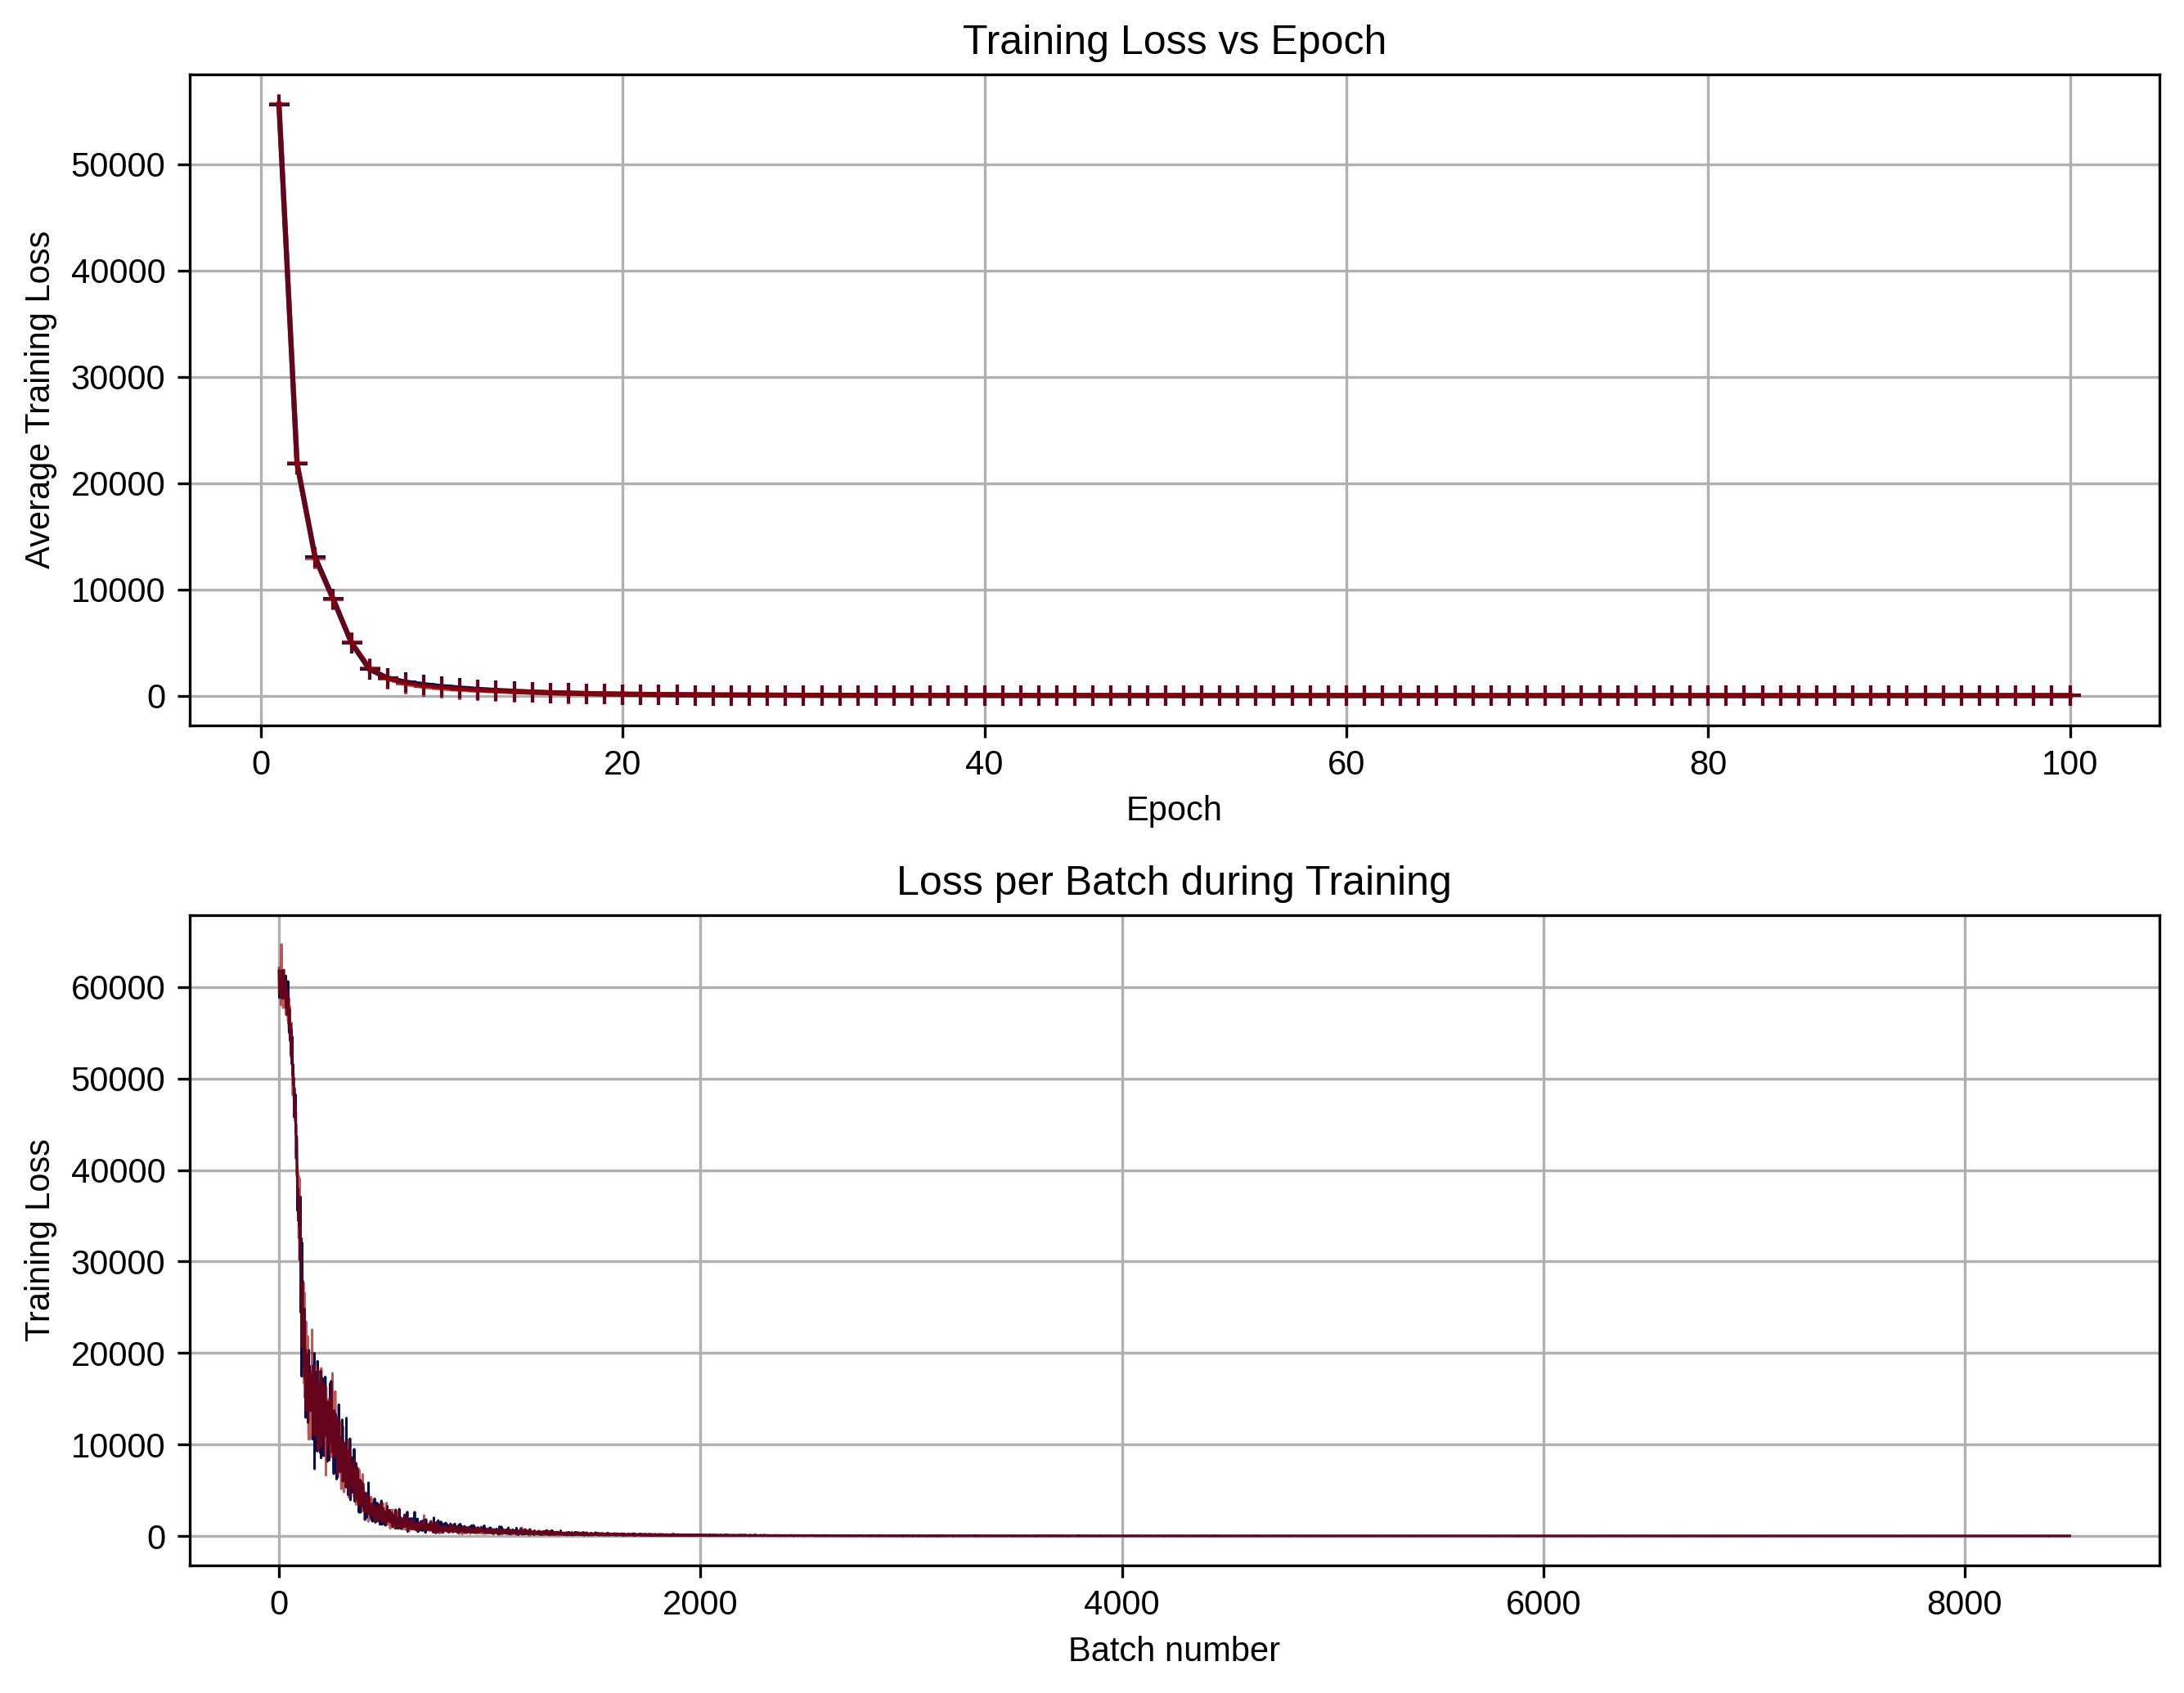

In [114]:
plt.figure(figsize=(9,7))

plt.subplot(2,1,1)
plt.plot(range(1, epochs+1), epoch_losses, marker='+', color=dtu_navy)
plt.plot(range(1, epochs+1), epoch_losses2, marker='+', color=dtu_red, alpha=0.65)
plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Training Loss vs Epoch")
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(all_batch_losses, linewidth=0.7, color=dtu_navy)
plt.plot(all_batch_losses2, linewidth=0.7, color=dtu_red, alpha=0.65)
plt.xlabel("Batch number")
plt.ylabel("Training Loss")
plt.title("Loss per Batch during Training")
plt.grid(True)

plt.tight_layout()
plt.show()

### Evaluation between the models

In [115]:
model.eval()
model2.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
    y_pred = model(X_test_tensor).numpy()
    X_test_tensor2 = torch.tensor(X_test_scaled2, dtype=torch.float32)
    y_pred2 = model2(X_test_tensor2).numpy()

In [116]:
# Compute residuals from averaged predictions
y_test_np = np.array(y_test).flatten()
y_test_np2 = np.array(y_test2).flatten()

y_pred_np = np.array(y_pred).flatten()
y_pred_np2 = np.array(y_pred2).flatten()

# Compute mean and std of residuals from averaged predictions
std_residuals = np.std(y_test_np - y_pred_np)
mean_residuals = np.mean(y_test_np - y_pred_np)

std_residuals2 = np.std(y_test_np2 - y_pred_np2)
mean_residuals2 = np.mean(y_test_np2 - y_pred_np2)


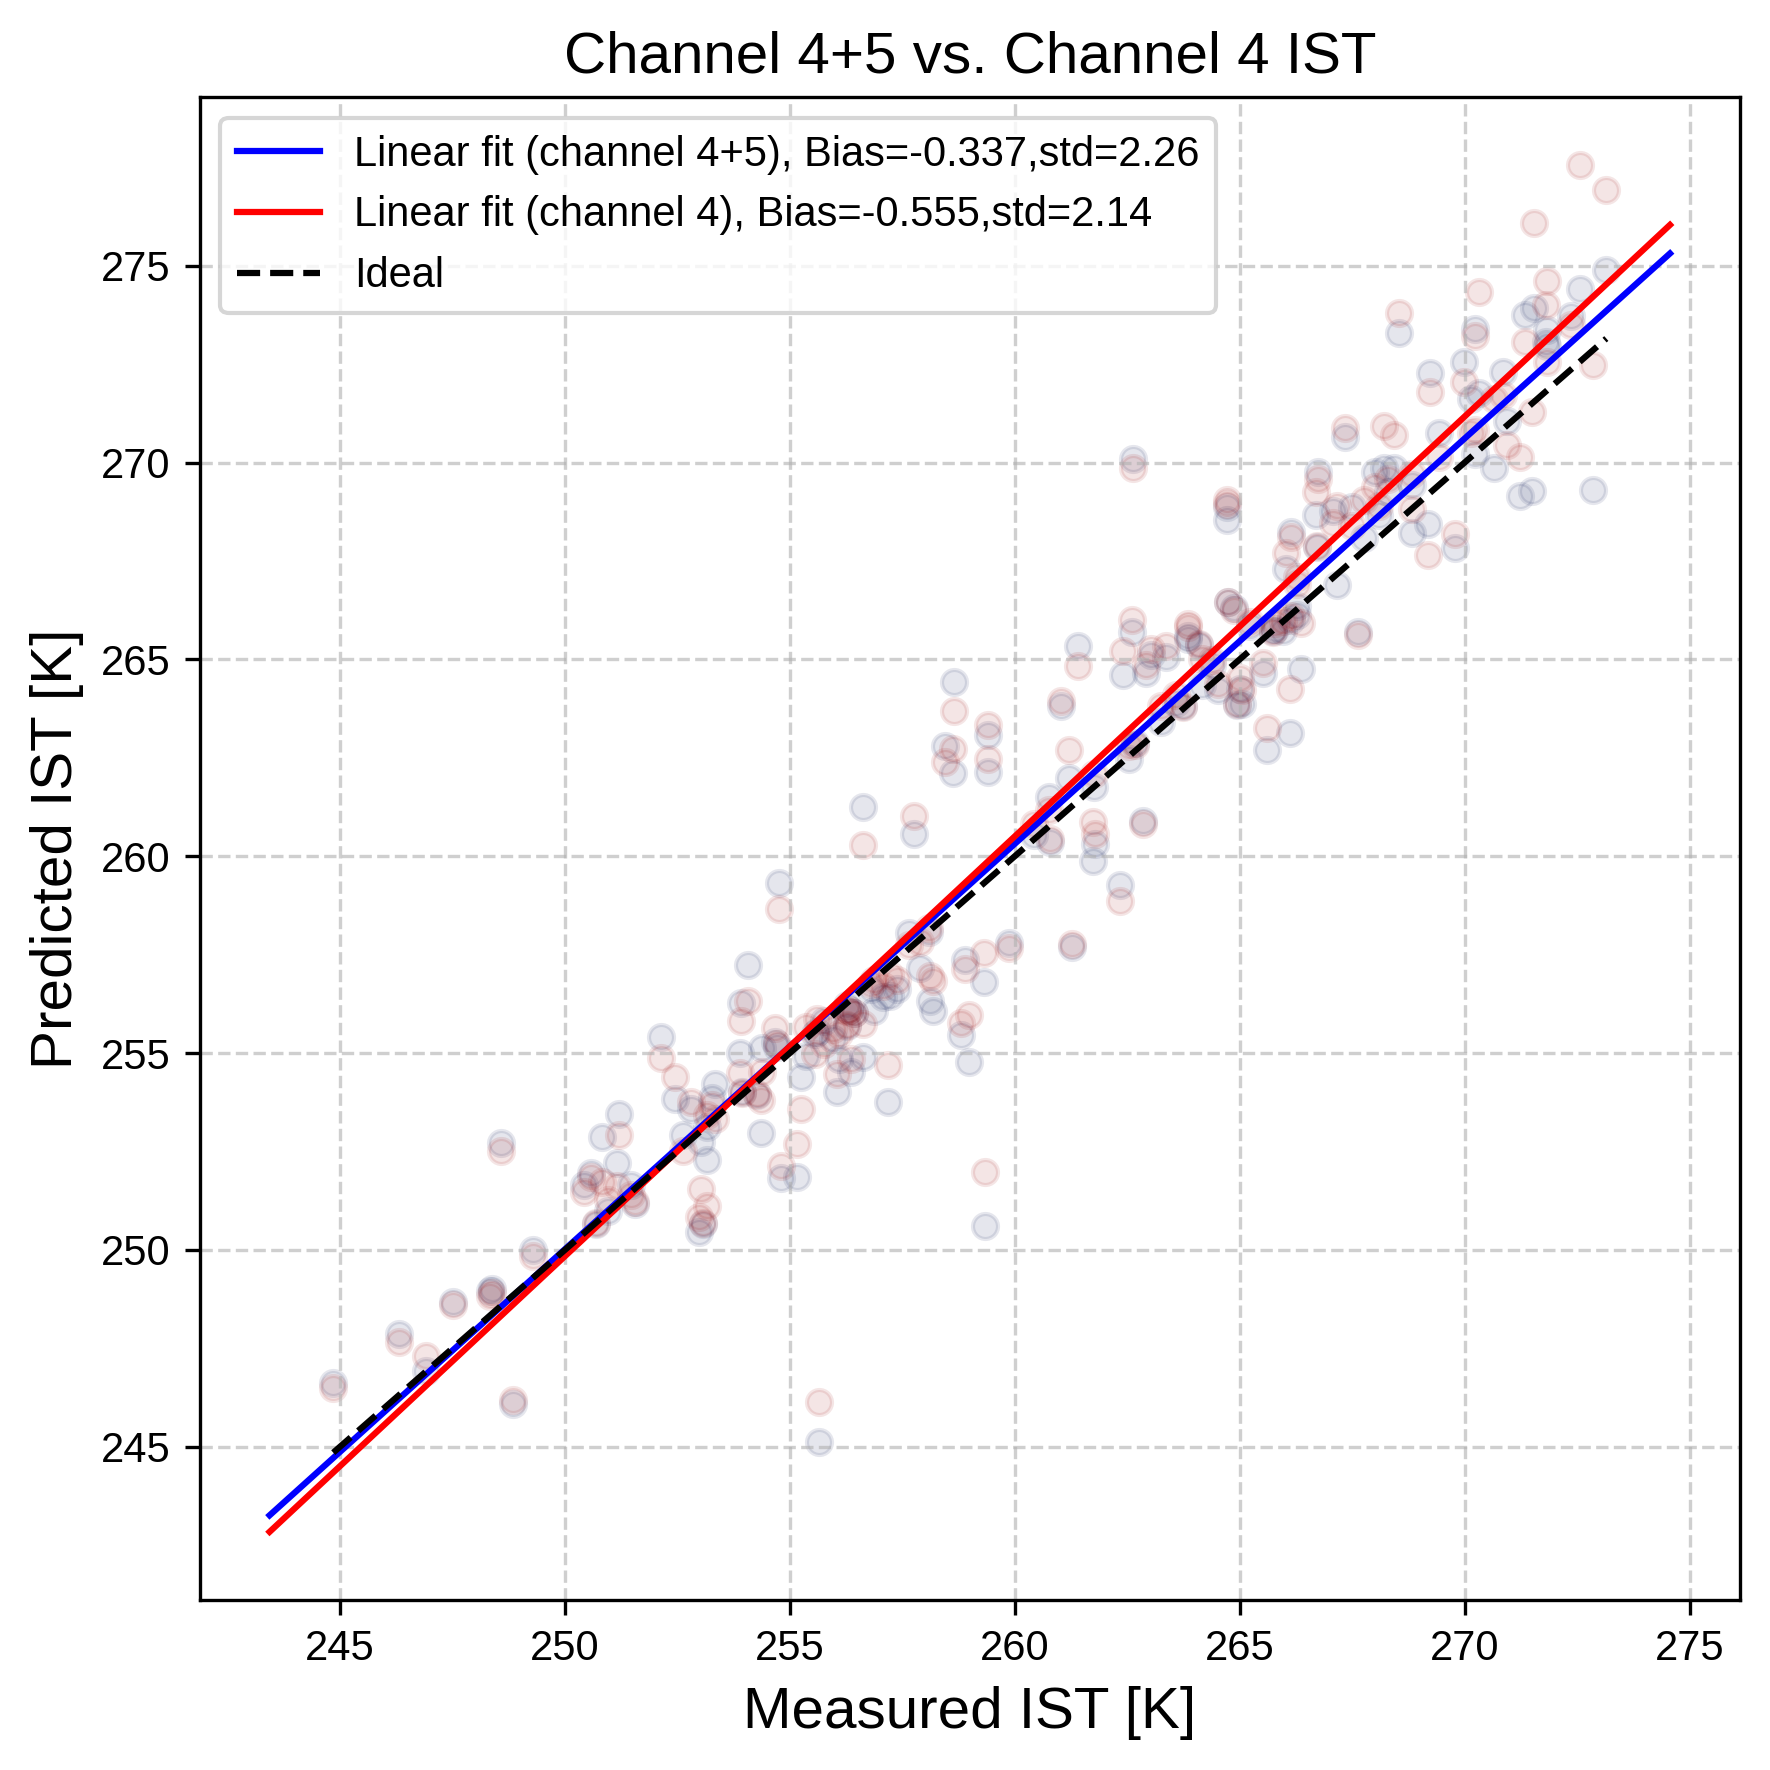

In [117]:
matplotlib.rcParams['figure.dpi'] = 300 # DPI figures - makes them ugly in vscode. Too bad
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_np, alpha=0.1, color=dtu_navy)
plt.scatter(y_test2, y_pred_np2, alpha=0.1, color=dtu_red)

slope, intercept, r_value, p_value, std_err = linregress(y_test, y_pred_np)
slope2, intercept2, r_value2, p_value2, std_err2 = linregress(y_test2, y_pred_np2)
x_vals = np.array(plt.xlim())  # take x axis limits
y_vals = intercept + slope * x_vals
y_vals2 = intercept2 + slope2 * x_vals
plt.plot(x_vals, y_vals, color='blue', label=f"Linear fit (channel 4+5), Bias={mean_residuals:.3f},std={std_residuals:.2f}")
plt.plot(x_vals, y_vals2, color='red', label=f"Linear fit (channel 4), Bias={mean_residuals2:.3f},std={std_residuals2:.2f}")

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'k--', label="Ideal")
plt.title("Channel 4+5 vs. Channel 4 IST", fontsize = 14) 
plt.xlabel("Measured IST [K]", fontsize = 14)
plt.ylabel("Predicted IST [K]", fontsize = 14)
plt.legend(loc='upper left') #title="Fits",
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

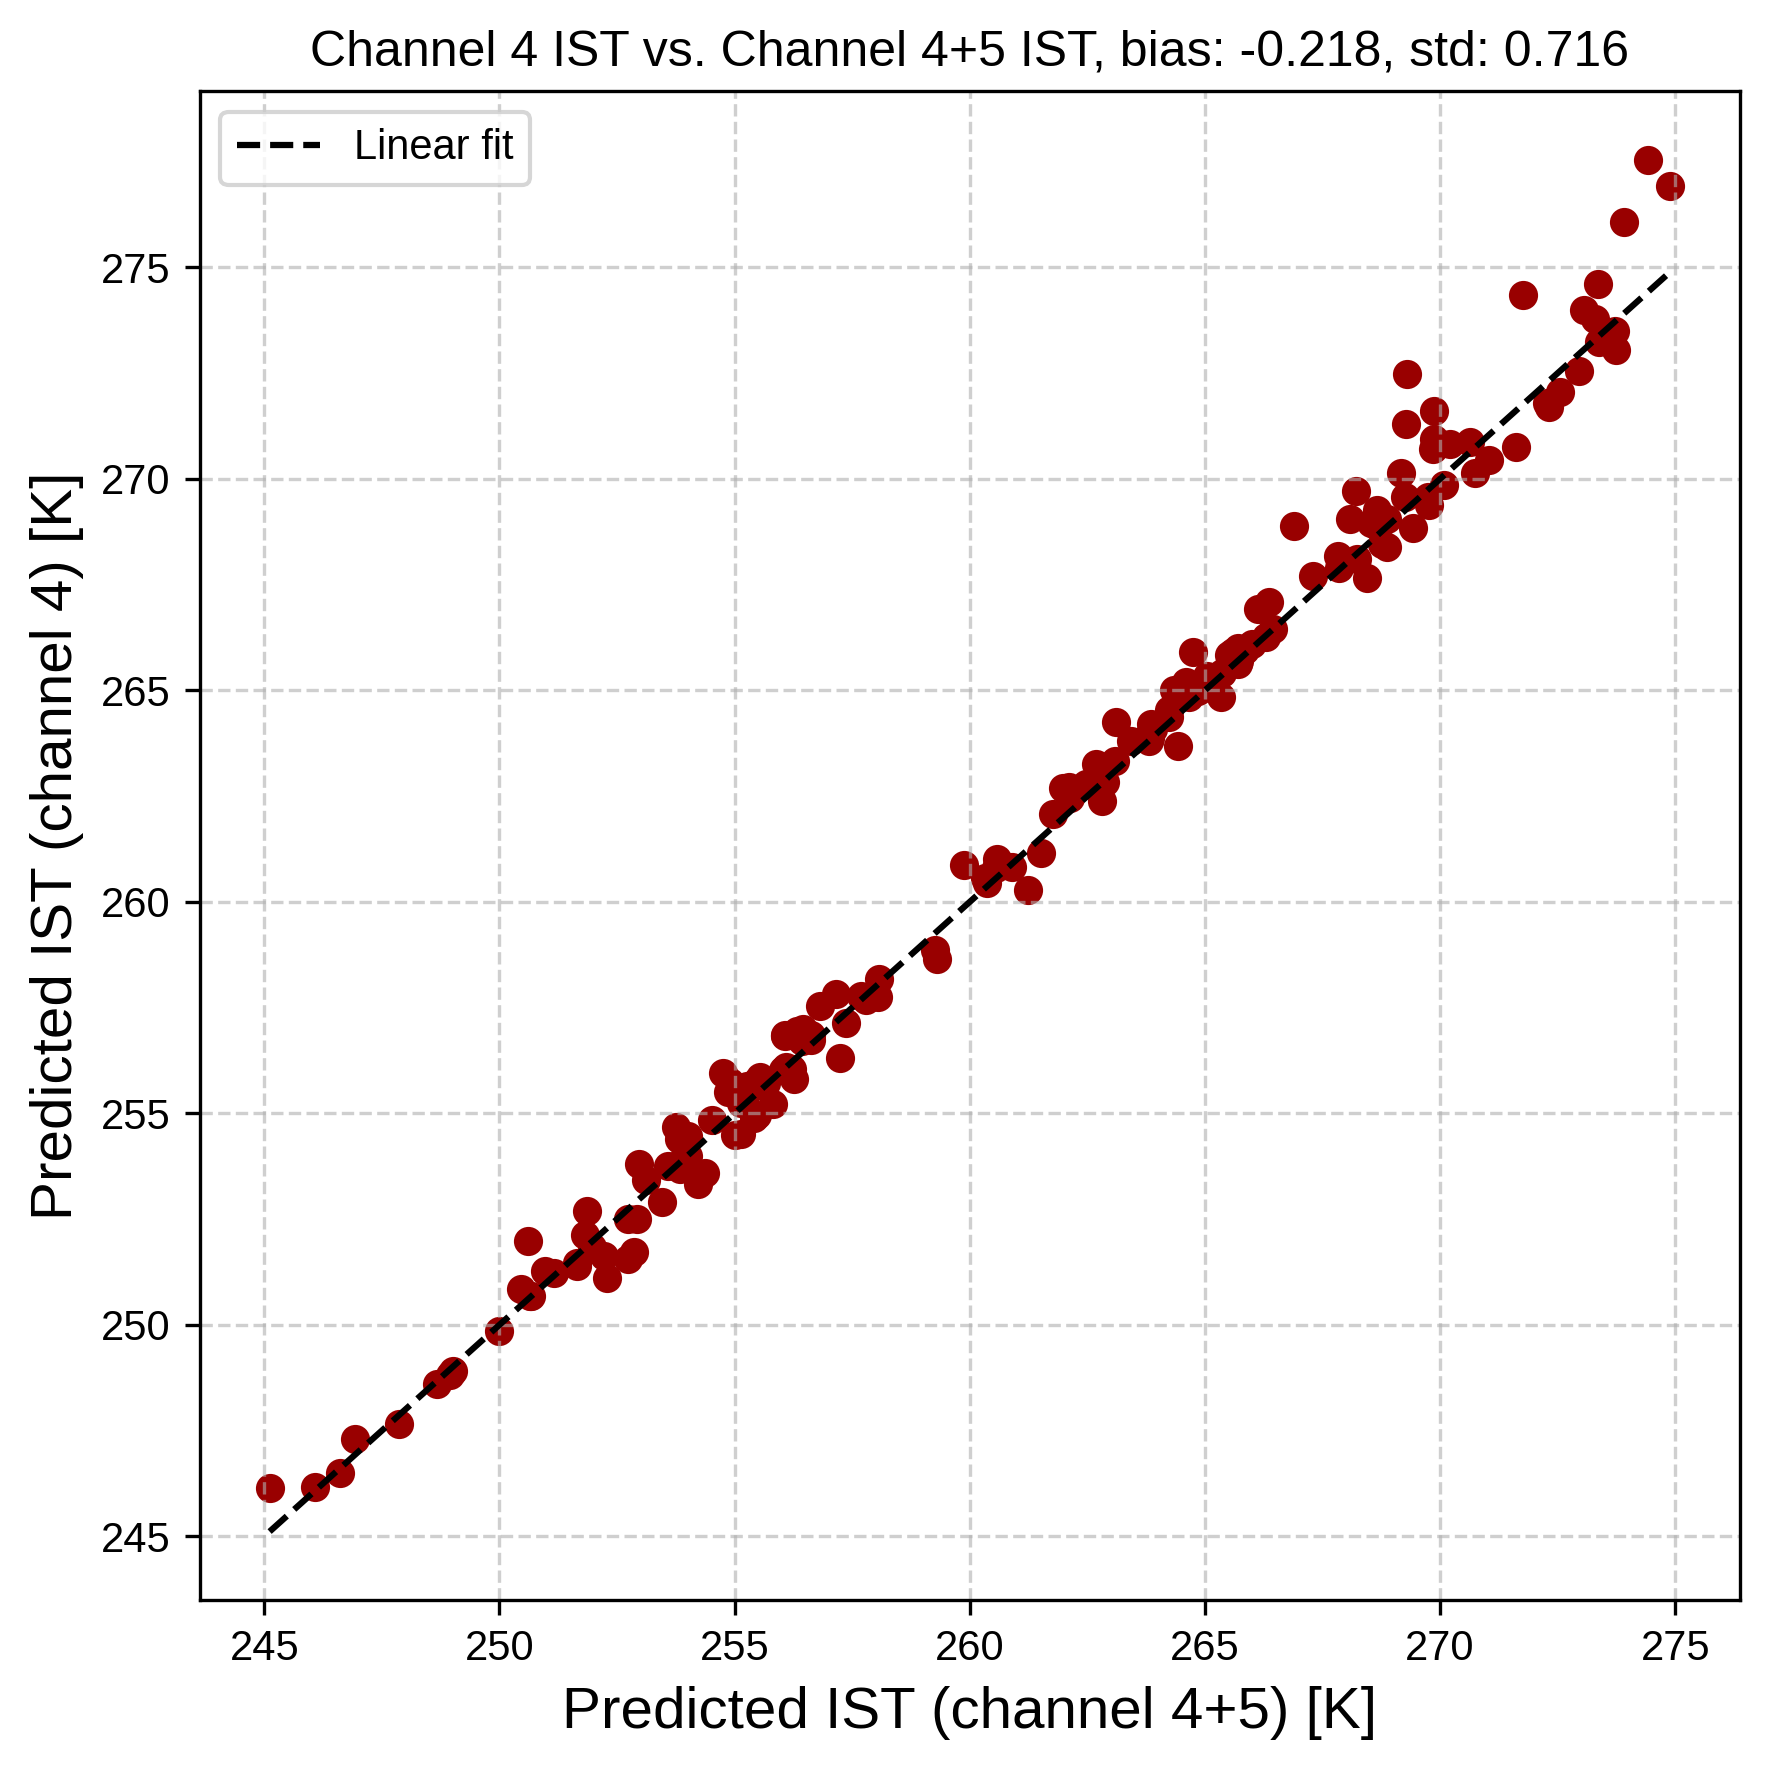

In [118]:
# Comparison of channel4 vs channel4+5
std_diff = np.std(y_pred_np - y_pred_np2)
mean_diff = np.mean(y_pred_np - y_pred_np2)

plt.figure(figsize=(6,6))

plt.scatter(y_pred_np,y_pred_np2, color=dtu_red)
plt.plot([min(y_pred_np),max(y_pred_np)],[min(y_pred_np),max(y_pred_np)], 'k--', label="Linear fit")

plt.xlabel("Predicted IST (channel 4+5) [K]", fontsize=14)
plt.ylabel("Predicted IST (channel 4) [K]", fontsize=14)
plt.legend(loc='upper left')
plt.title(f"Channel 4 IST vs. Channel 4+5 IST, bias: {mean_diff:.3f}, std: {std_diff:.3f}")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Statistics for comparison

In [119]:
from tabulate import tabulate
from IPython.display import HTML, display
std = std_residuals
std2 = std_residuals2
var = std**2
var2 = std2**2
Bias = mean_residuals
Bias2 = mean_residuals2

# Use averaged predictions across all runs
MAE = mean_absolute_error(y_test_np, y_pred_np)
MAE2 = mean_absolute_error(y_test_np2, y_pred_np2)
RMSE = root_mean_squared_error(y_test_np, y_pred_np)
RMSE2 = root_mean_squared_error(y_test_np2, y_pred_np2)
#kfold = KFold(n_splits=15)
#kfold2 = KFold(n_splits=15)

output = [
   ['parameter', 'ch4','ch4+5'],
   ['MAE',MAE2,MAE],
   ['RMSE',RMSE2,RMSE],
   #['K-fold CV',kfold2,kfold],
   ['Variance',var2,var],
   ['Std',std2,std],
   ['Bias',Bias2,Bias]
   ]
output_df = tabulate(output, tablefmt='html')
display(HTML(output_df))

parameter,ch4,ch4+5
MAE,1.5957995713815183,1.6457293845633796
RMSE,2.206979462495614,2.280360582316153
Variance,4.562874309847595,5.086365782248028
Std,2.136088553840312,2.2552972713697916
Bias,-0.5548729927017847,-0.3371625767092736


## Day of year plots

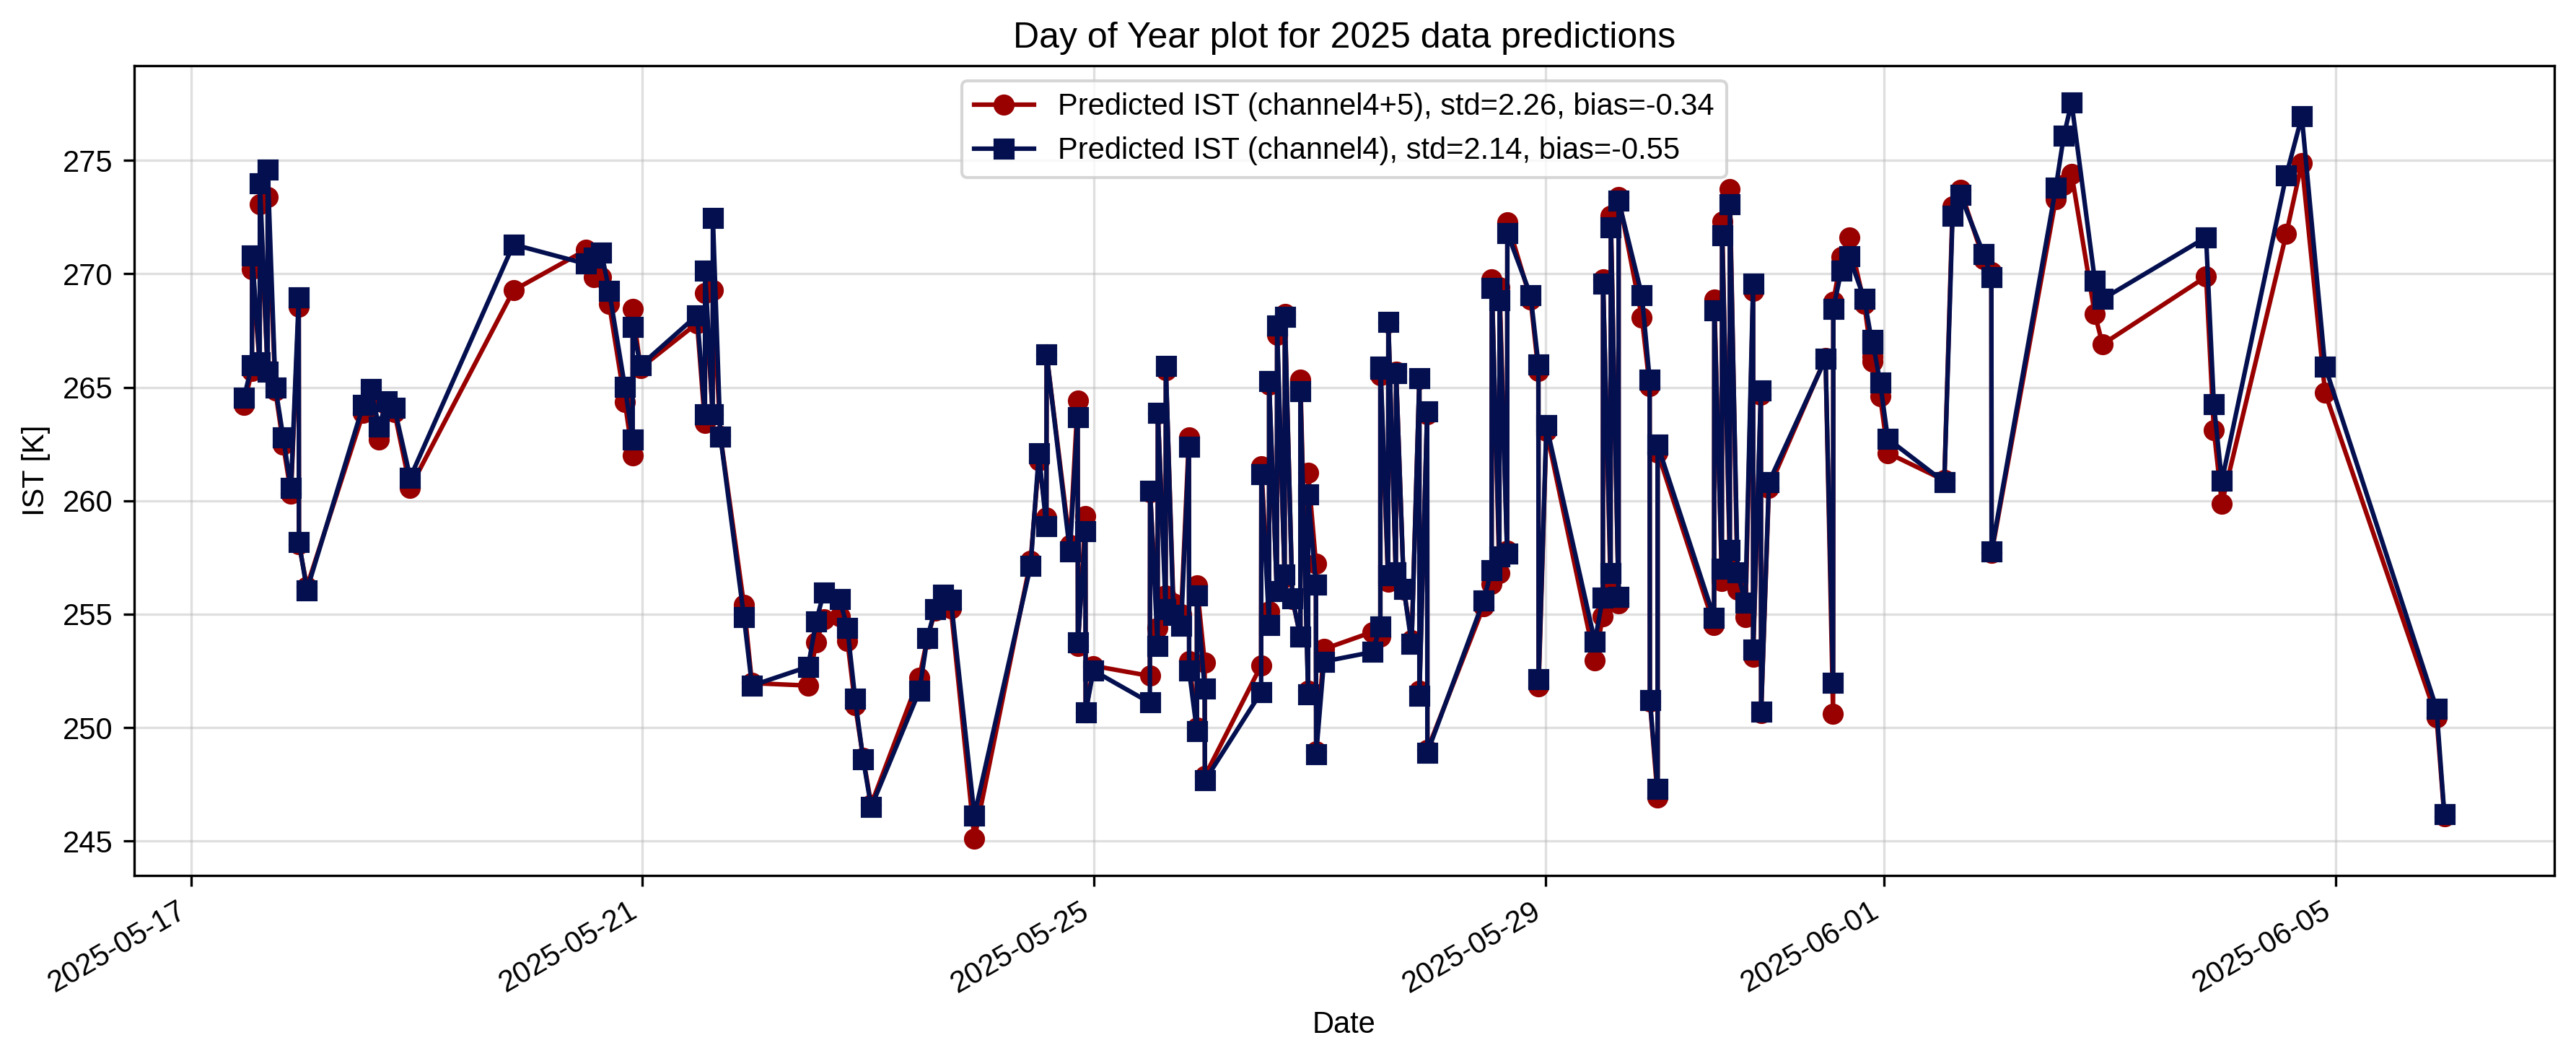

In [120]:
# DoY plots for ch4 and ch4+5
# want to see how the IST changes throughout the year. How well do the models predict in cold vs. warm months?

# Predict on full dataset for all days
X_full = df_clean_test[available_input_features].values
X_full_scaled = (X_full - train_mean) / train_std
X_full_tensor = torch.tensor(X_full_scaled, dtype=torch.float32)
with torch.no_grad():
    preds_full = model(X_full_tensor)
y_pred_full = preds_full.numpy()

X_full2 = df_clean_test2[available_input_features2].values
X_full_scaled2 = (X_full2 - train_mean2) / train_std2
X_full_tensor2 = torch.tensor(X_full_scaled2, dtype=torch.float32)
with torch.no_grad():
    preds_full2 = model2(X_full_tensor2)
y_pred_full2 = preds_full2.numpy()

xvals_full = pd.to_datetime(df_clean_test['lev1_obstime'].values)
xvals_full2 = pd.to_datetime(df_clean_test2['lev1_obstime'].values)

plt.figure(figsize=(12, 5))
plt.plot(xvals_full, y_pred_full, color=dtu_red, marker='o', linestyle='-', label=f'Predicted IST (channel4+5), std={std:.2f}, bias={Bias:.2f}')
plt.plot(xvals_full2, y_pred_full2, color=dtu_navy, marker='s', linestyle='-', label=f'Predicted IST (channel4), std={std2:.2f}, bias={Bias2:.2f}')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.xlabel('Date')
plt.ylabel('IST [K]')
plt.title('Day of Year plot for 2025 data predictions')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

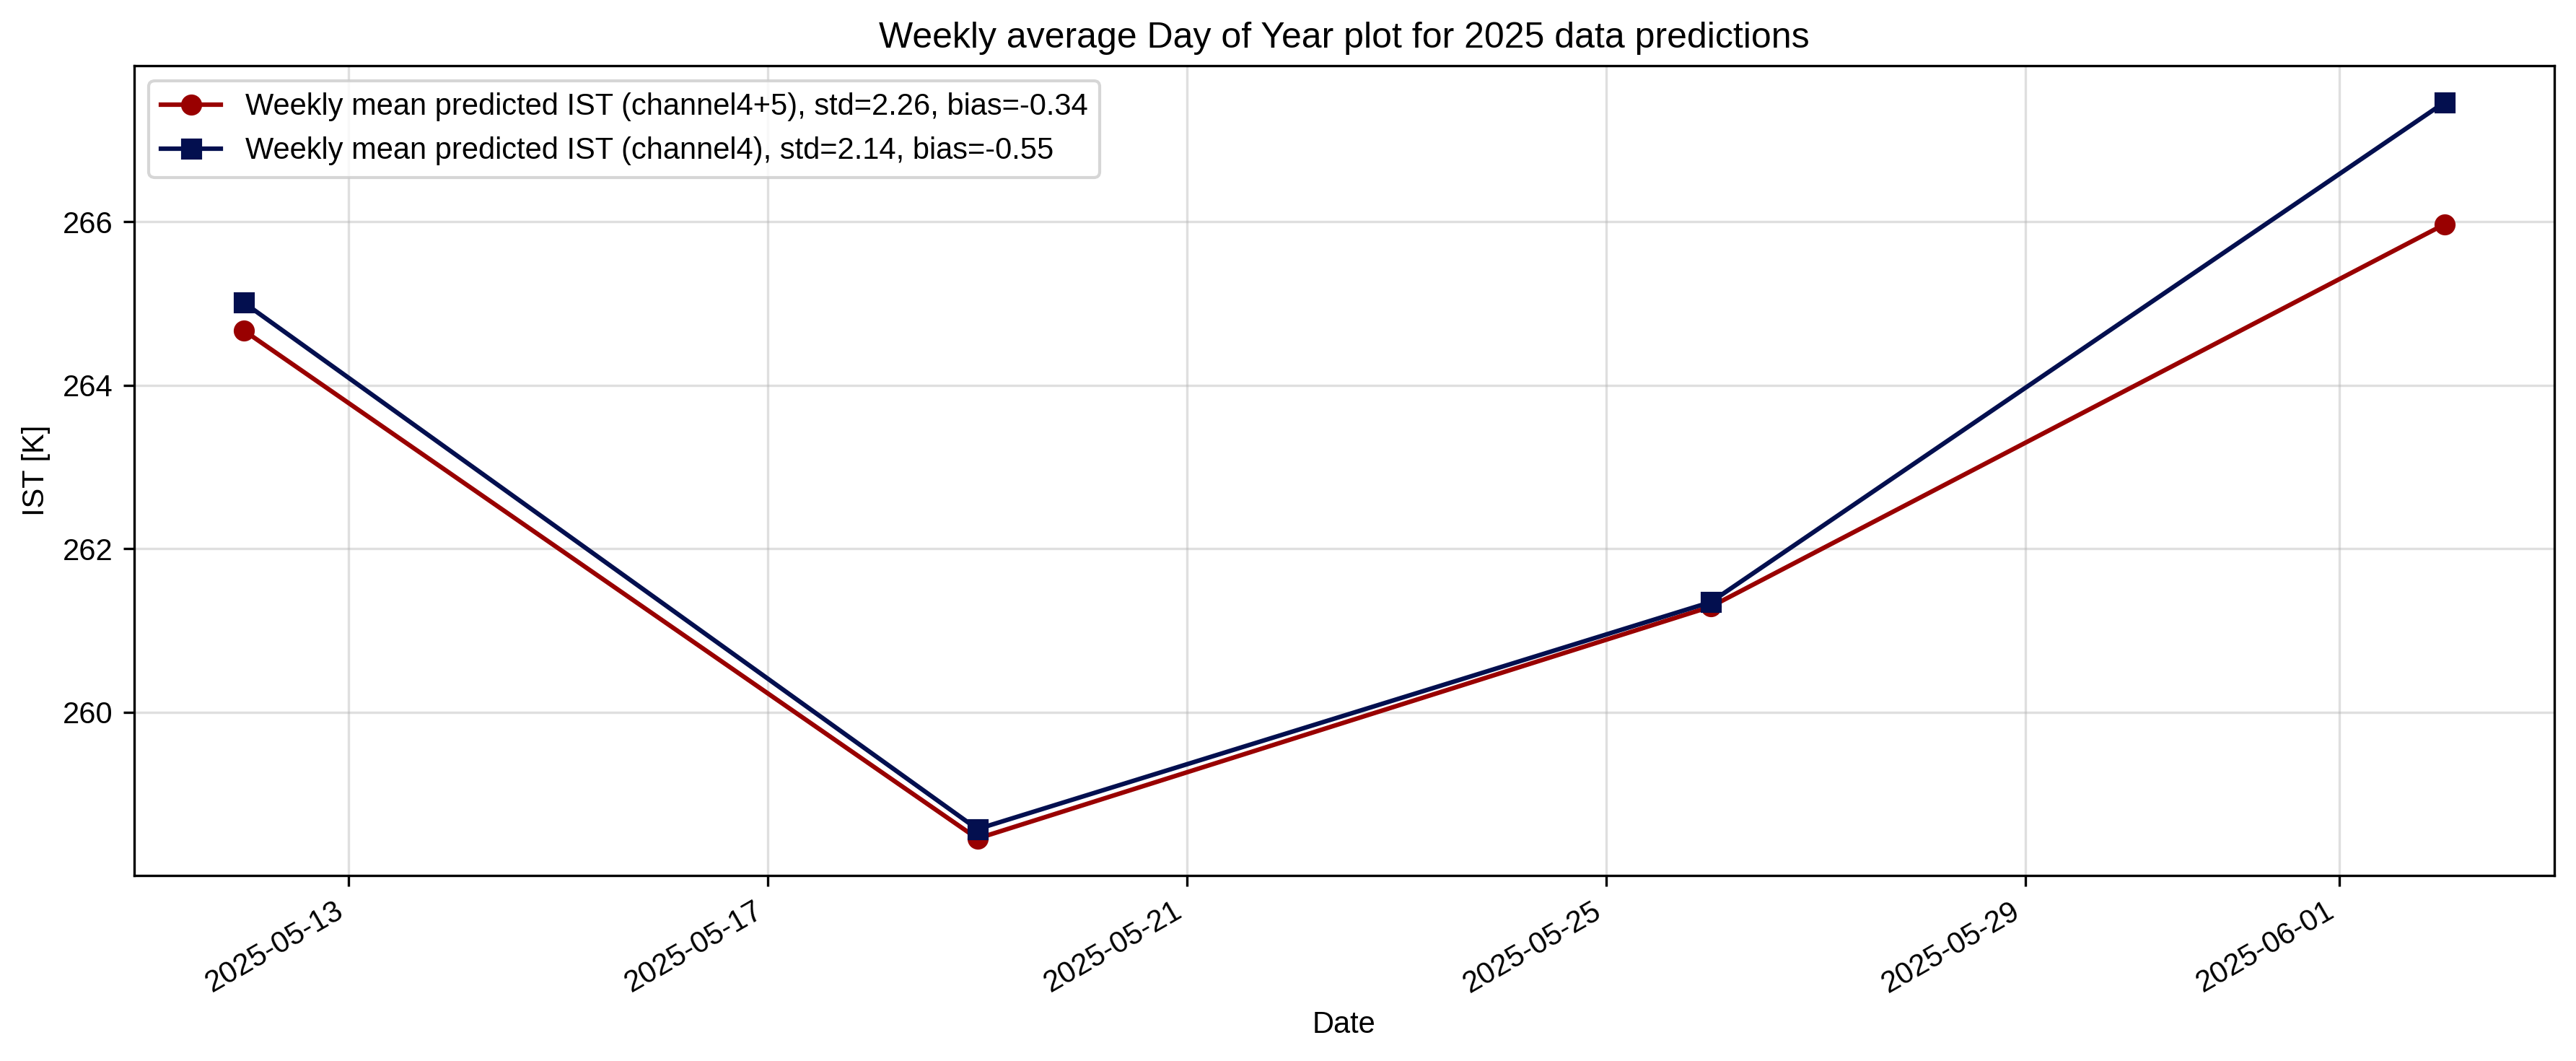

In [121]:
# Day of Year plot with weekly avg. for easier readability
# Predict on full dataset for all days
X_full = df_clean_test[available_input_features].values
X_full_scaled = (X_full - train_mean) / train_std
X_full_tensor = torch.tensor(X_full_scaled, dtype=torch.float32)
with torch.no_grad():
    preds_full = model(X_full_tensor)
y_pred_full = preds_full.numpy()

X_full2 = df_clean_test2[available_input_features2].values
X_full_scaled2 = (X_full2 - train_mean2) / train_std2
X_full_tensor2 = torch.tensor(X_full_scaled2, dtype=torch.float32)
with torch.no_grad():
    preds_full2 = model2(X_full_tensor2)
y_pred_full2 = preds_full2.numpy()

# weekly avg aggregation for readability
weekly_df1 = pd.DataFrame({
    'datetime': pd.to_datetime(df_clean_test['lev1_obstime'].values),
    'pred': y_pred_full.flatten()
}).set_index('datetime').resample('W-MON', label='left', closed='left').mean()

weekly_df2 = pd.DataFrame({
    'datetime': pd.to_datetime(df_clean_test2['lev1_obstime'].values),
    'pred': y_pred_full2.flatten()
}).set_index('datetime').resample('W-MON', label='left', closed='left').mean()

plt.figure(figsize=(12, 5))
plt.plot(weekly_df1.index, weekly_df1['pred'], marker='o', linestyle='-', color=dtu_red,
         label=f'Weekly mean predicted IST (channel4+5), std={std:.2f}, bias={Bias:.2f}')
plt.plot(weekly_df2.index, weekly_df2['pred'], marker='s', linestyle='-', color=dtu_navy,
         label=f'Weekly mean predicted IST (channel4), std={std2:.2f}, bias={Bias2:.2f}')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.xlabel('Date')
plt.ylabel('IST [K]')
plt.title('Weekly average Day of Year plot for 2025 data predictions')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

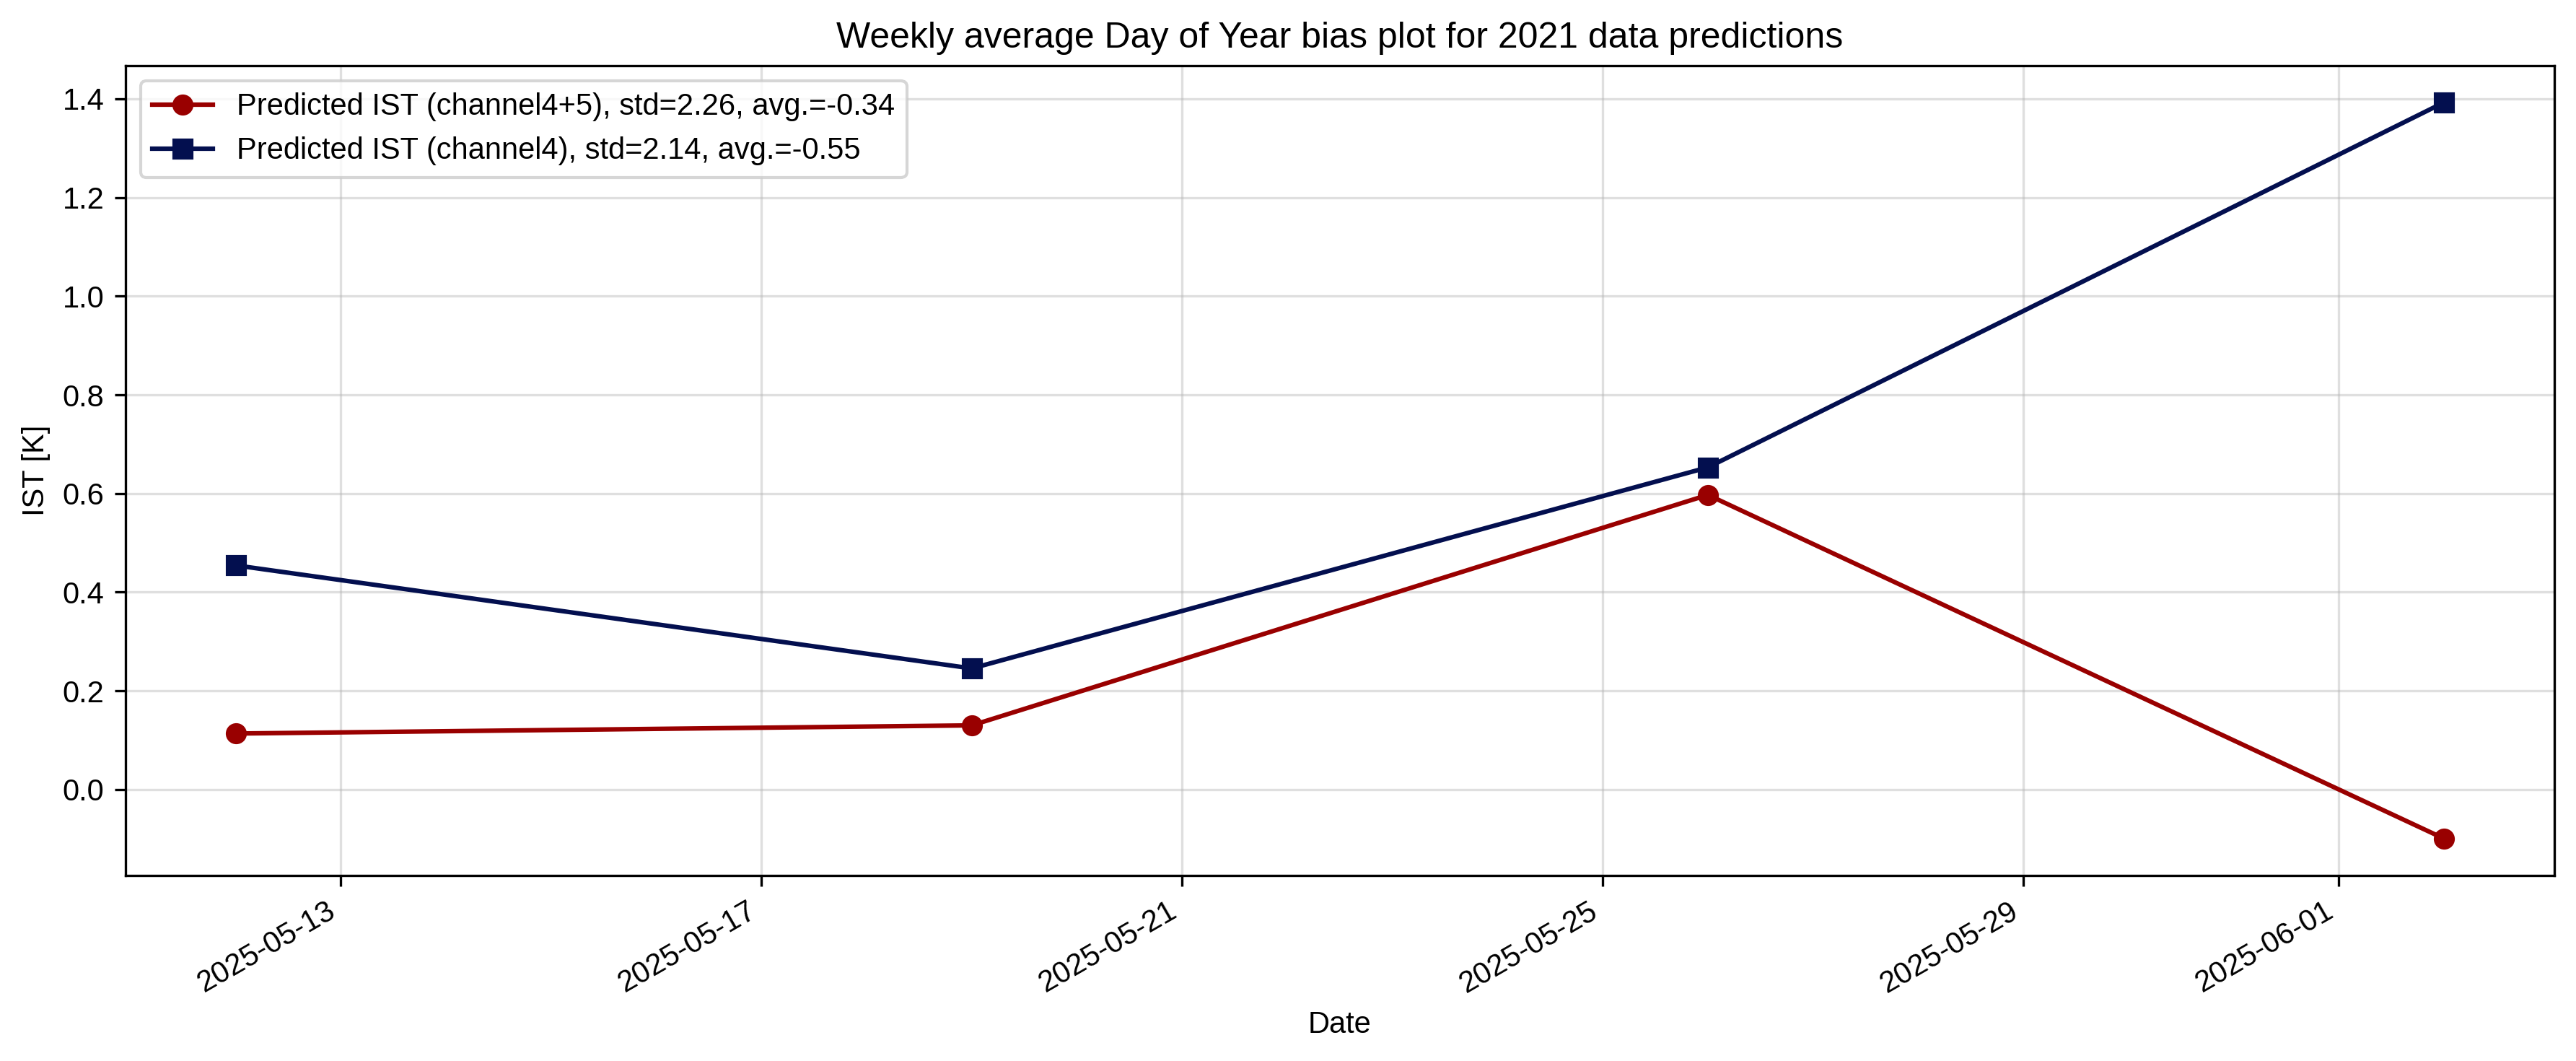

In [122]:
# Bias Day of Year - weekly avg.
# Predict on full dataset for all days
X_full = df_clean_test[available_input_features].values
X_full_scaled = (X_full - train_mean) / train_std
X_full_tensor = torch.tensor(X_full_scaled, dtype=torch.float32)
with torch.no_grad():
    preds_full = model(X_full_tensor)
y_pred_full = preds_full.numpy()
y_pred_series = pd.Series(y_pred_full.ravel(), index=df_clean_test.index, name='pred')
resid_series = y_pred_series - df_clean_test[target_column]
df_clean_test['resid'] = resid_series


X_full2 = df_clean_test2[available_input_features2].values
X_full_scaled2 = (X_full2 - train_mean2) / train_std2
X_full_tensor2 = torch.tensor(X_full_scaled2, dtype=torch.float32)
with torch.no_grad():
    preds_full2 = model2(X_full_tensor2)
y_pred_full2 = preds_full2.numpy()
y_pred_series = pd.Series(y_pred_full2.ravel(), index=df_clean_test2.index, name='pred')
resid_series = y_pred_series - df_clean_test2[target_column]
df_clean_test2['resid'] = resid_series

xvals_full = pd.to_datetime(df_clean_test['lev1_obstime'].values)
xvals_full2 = pd.to_datetime(df_clean_test2['lev1_obstime'].values)

yvals1 = df_clean_test.set_index(pd.to_datetime(df_clean_test['lev1_obstime'])).resample('W-MON', label='left', closed='left')['resid'].mean()
yvals2 = df_clean_test2.set_index(pd.to_datetime(df_clean_test2['lev1_obstime'])).resample('W-MON', label='left', closed='left')['resid'].mean()
xvals1 = yvals1.index
xvals2 = yvals2.index

plt.figure(figsize=(12, 5))
plt.plot(xvals1, yvals1, color=dtu_red, marker="o", label=f'Predicted IST (channel4+5), std={std:.2f}, avg.={Bias:.2f}')
plt.plot(xvals2, yvals2, color=dtu_navy, marker="s", label=f'Predicted IST (channel4), std={std2:.2f}, avg.={Bias2:.2f}')


# Bars for season changes
#plt.axvline(x=datetime.datetime(2024,12,1), color='k', alpha=.4, linestyle='--') # winter
#plt.axvline(x=datetime.datetime(2025,3,1), color='k', alpha=.4, linestyle='--') # spring
#plt.axvline(x=datetime.datetime(2025,6,1), color='k', alpha=.4, linestyle='--') # summer
#plt.axvline(x=datetime.datetime(2025,9,1), color='k', alpha=.4, linestyle='--', label="Date for change in season") # autumn

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.xlabel('Date')
plt.ylabel('IST [K]')
plt.title('Weekly average Day of Year bias plot for 2021 data predictions')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()

plt.show()

# ML vs. Classic

In [132]:
# Import classical algorithms (2,8,9)
from IST_retrievals import ist_retrievals

# Use the cleaned test subsets so classical algorithms align with the ML predictions
classical_test_2ch = df_clean_test[['lev1_channel4', 'lev1_channel5', 'lev1_satzenith_angle', 'lev1_obstime']].copy()

classical_test_1ch = pd.DataFrame({
    'lev1_channel4': df_clean_test2['lev1_channel4'],
    'lev1_satzenith_angle': df_test.loc[df_clean_test2.index, 'lev1_satzenith_angle'],
    'lev1_obstime': df_clean_test2['lev1_obstime']
})

algo2 = ist_retrievals(2, Tb11n=classical_test_2ch['lev1_channel4'], Tb12n=classical_test_2ch['lev1_channel5'])
algo8 = ist_retrievals(8, Tb11n=classical_test_1ch['lev1_channel4'])
algo9 = ist_retrievals(9, Tb11n=classical_test_1ch['lev1_channel4'], thetan=np.deg2rad(classical_test_1ch['lev1_satzenith_angle']))

# correlation between algo8 and algo9
slope, intercept = np.polyfit(algo8[0], algo9[0], 1)
print(slope)


0.9994038750308715


## Classical algorithms vs. ML

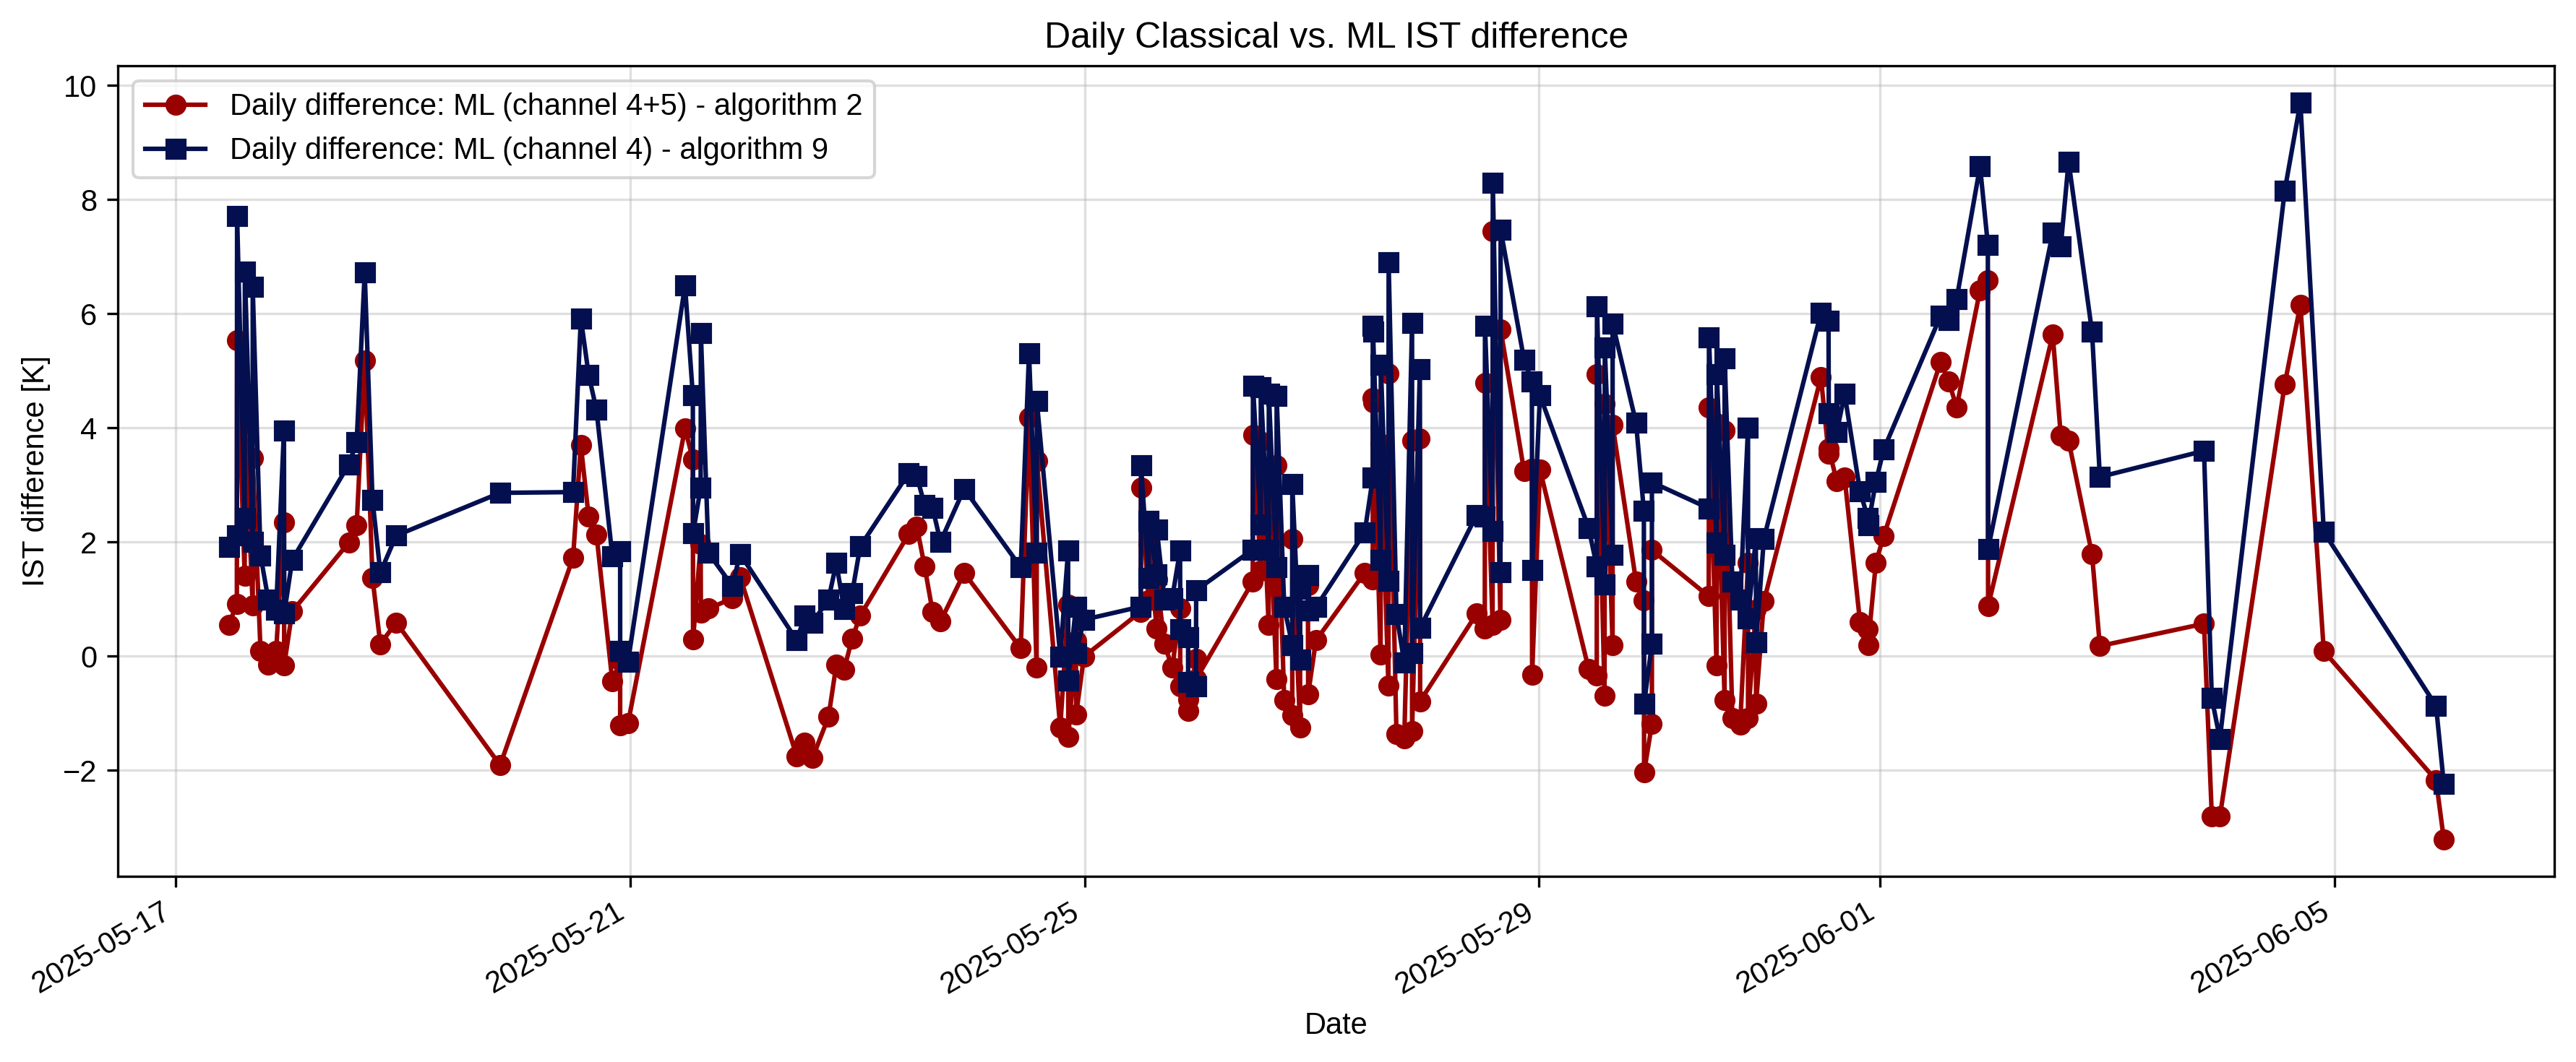

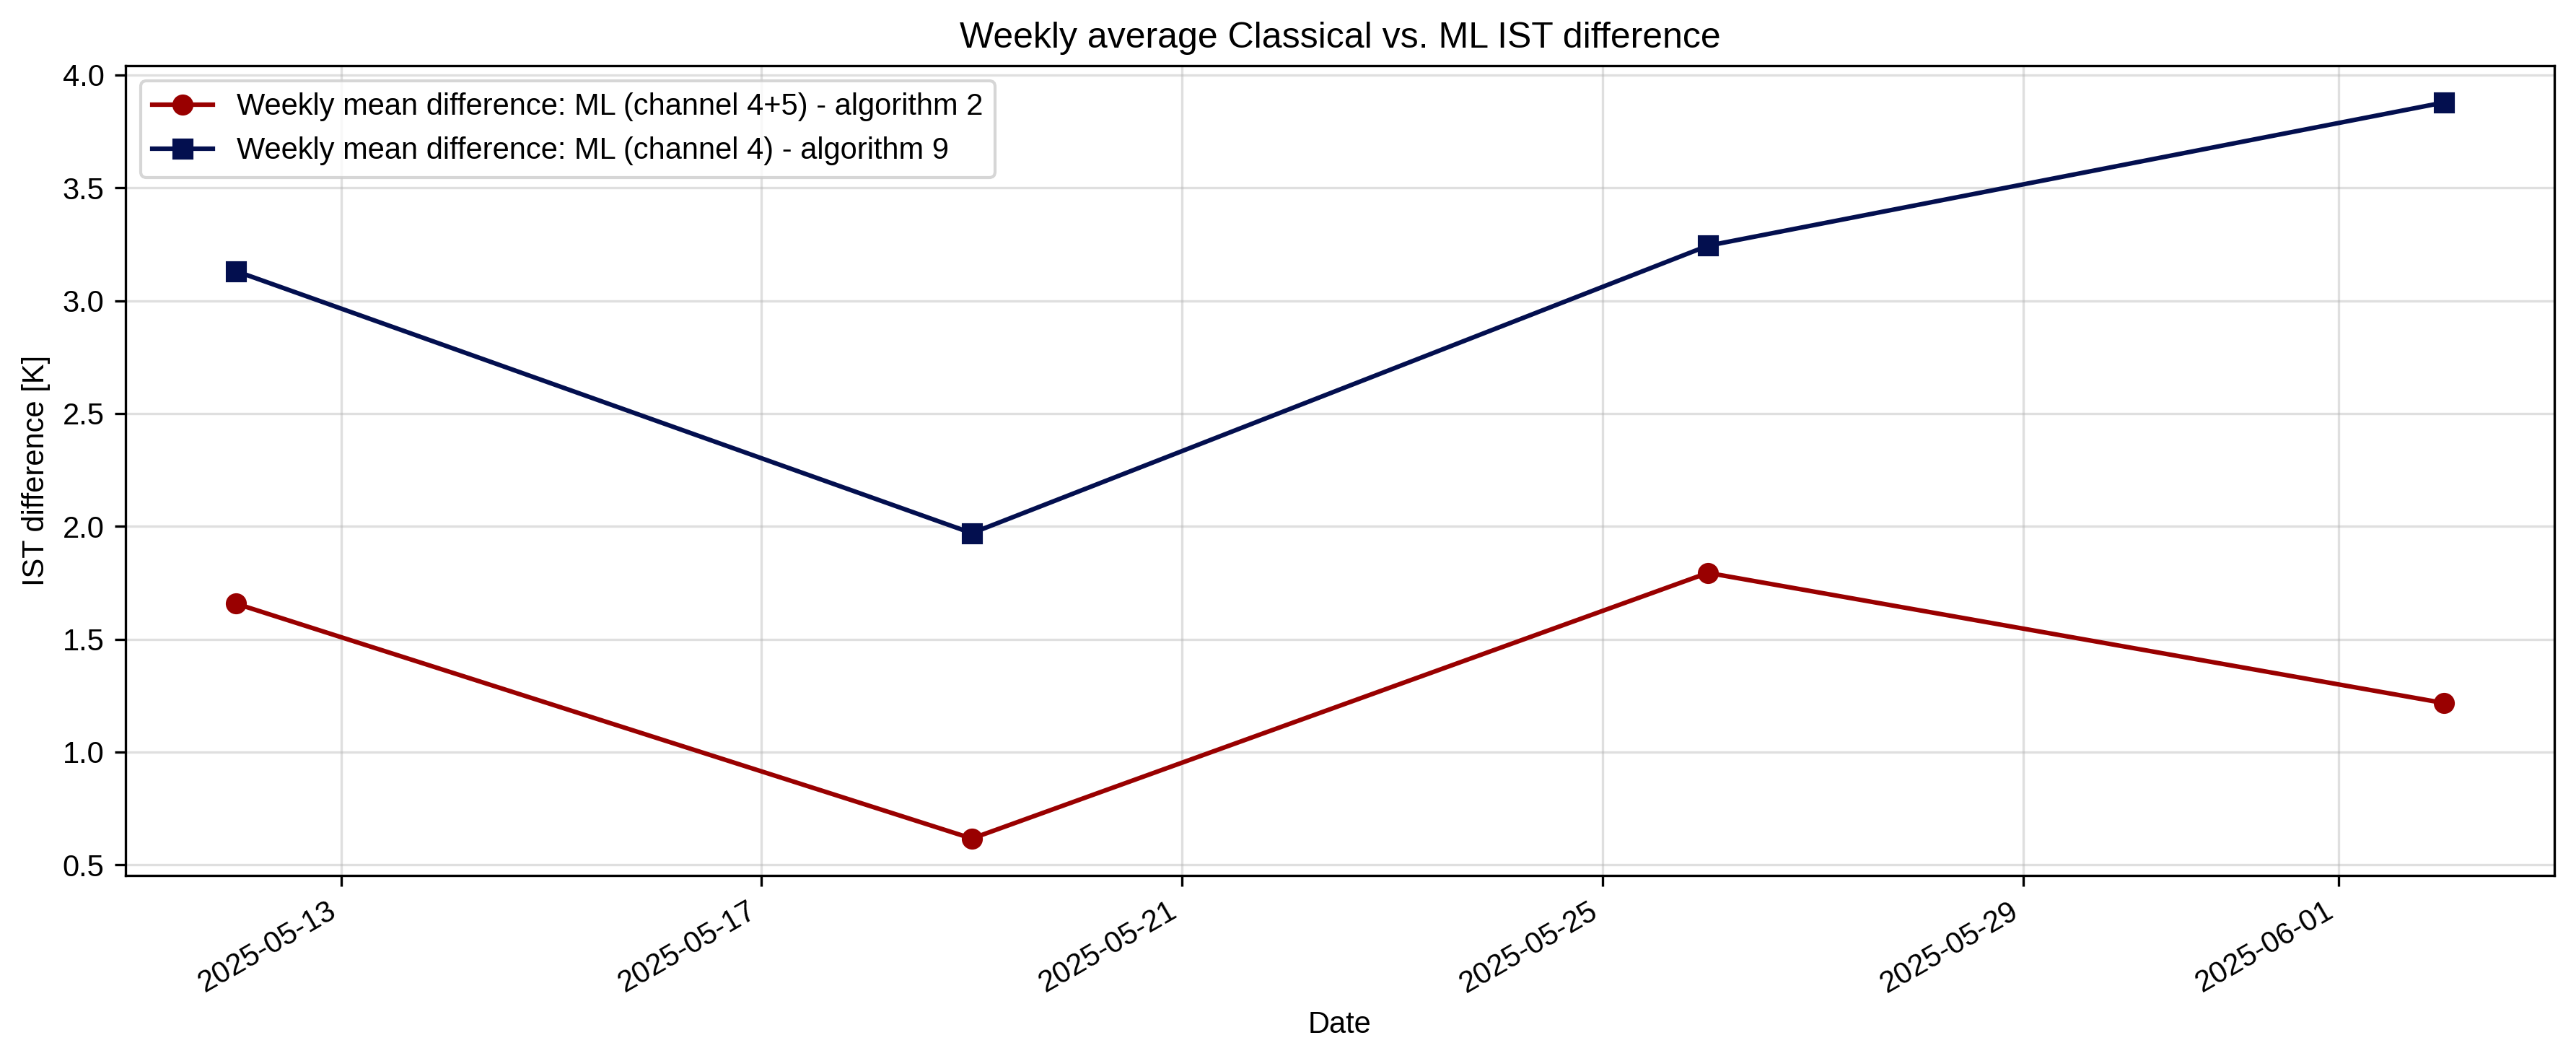

In [134]:
# Daily ML vs. classic algorithm differences
# Use aligned cleaned subsets for each comparison
daily_ypred = pd.DataFrame({
    'datetime': pd.to_datetime(df_clean_test['lev1_obstime'].values),
    'pred': y_pred_full.flatten()
})

daily_algo2 = pd.DataFrame({
    'datetime': pd.to_datetime(classical_test_2ch['lev1_obstime'].values),
    'pred': algo2[0]
})

# algo9 vs. 1-channel
daily_ypred2 = pd.DataFrame({
    'datetime': pd.to_datetime(df_clean_test2['lev1_obstime'].values),
    'pred': y_pred_full2.flatten()
})

daily_algo9 = pd.DataFrame({
    'datetime': pd.to_datetime(classical_test_1ch['lev1_obstime'].values),
    'pred': algo9[0]
})

# Align by datetime to avoid indexing mismatches
daily_ypred = daily_ypred.set_index('datetime')
daily_algo2 = daily_algo2.set_index('datetime')
daily_ypred2 = daily_ypred2.set_index('datetime')
daily_algo9 = daily_algo9.set_index('datetime')

plt.figure(figsize=(12, 5))
plt.plot(daily_ypred.index,
         (daily_ypred['pred'] - daily_algo2['pred']).values,
         marker='o', linestyle='-', color=dtu_red,
         label='Daily difference: ML (channel 4+5) - algorithm 2')
plt.plot(daily_ypred2.index,
         (daily_ypred2['pred'] - daily_algo9['pred']).values,
         marker='s', linestyle='-', color=dtu_navy,
         label='Daily difference: ML (channel 4) - algorithm 9')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.xlabel('Date')
plt.ylabel('IST difference [K]')
plt.title('Daily Classical vs. ML IST difference')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# Weekly average ML vs. classic algorithm differences
weekly_ypred = daily_ypred.resample('W-MON', label='left', closed='left').mean()
weekly_algo2 = daily_algo2.resample('W-MON', label='left', closed='left').mean()
weekly_ypred2 = daily_ypred2.resample('W-MON', label='left', closed='left').mean()
weekly_algo9 = daily_algo9.resample('W-MON', label='left', closed='left').mean()

plt.figure(figsize=(12, 5))
plt.plot(weekly_ypred.index,
         (weekly_ypred['pred'] - weekly_algo2['pred']).values,
         marker='o', linestyle='-', color=dtu_red,
         label='Weekly mean difference: ML (channel 4+5) - algorithm 2')
plt.plot(weekly_ypred2.index,
         (weekly_ypred2['pred'] - weekly_algo9['pred']).values,
         marker='s', linestyle='-', color=dtu_navy,
         label='Weekly mean difference: ML (channel 4) - algorithm 9')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.xlabel('Date')
plt.ylabel('IST difference [K]')
plt.title('Weekly average Classical vs. ML IST difference')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()
